# Setup

In [1]:
pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [3]:
cs_df = pd.read_csv('https://raw.githubusercontent.com/jethzgg/Data-ML/refs/heads/main/Seaborn/ComputerSales.csv')
cs_df.head()

,Sale ID,Contact,Sex,Age,State,Product ID,Product Type,Sale Price,Profit,Lead,Month,Year
0,1,Paul Thomas,M,43,OH,M01-F0024,Desktop,479.99,143.39,Website,January,2018
1,2,Margo Simms,F,37,WV,GT13-0024,Desktop,1249.99,230.89,Flyer 4,January,2018
2,3,Sam Stine,M,26,PA,I3670,Desktop,649.99,118.64,Website,February,2018
3,4,Moe Eggert,M,35,PA,I3593,Laptop,399.99,72.09,Website,March,2018
4,5,Jessica Elk,F,55,PA,15M-ED,Laptop,699.99,98.09,Flyer 4,March,2018


In [4]:
crash_df = sns.load_dataset('car_crashes')
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


# Distribution Plots

### Distribution Plot

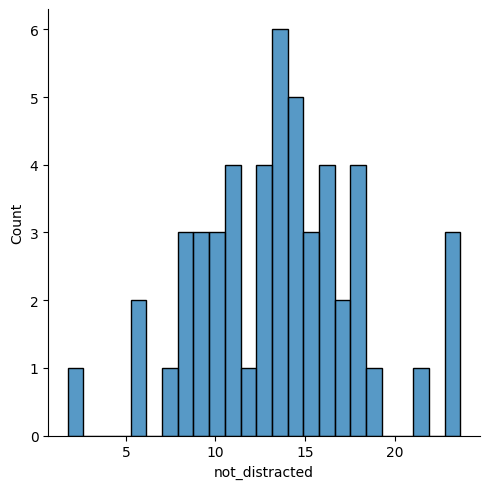

In [5]:
sns.displot(crash_df['not_distracted'], kde=False, bins=25)
# kde means the plot displays a line that represents the probability density function of the variable. It helps to visualize the distribution of the data more smoothly.

### Joint Plot

Compare the relationship between two variables and their distributions. It can be used to visualize the correlation between two variables and how they are distributed.

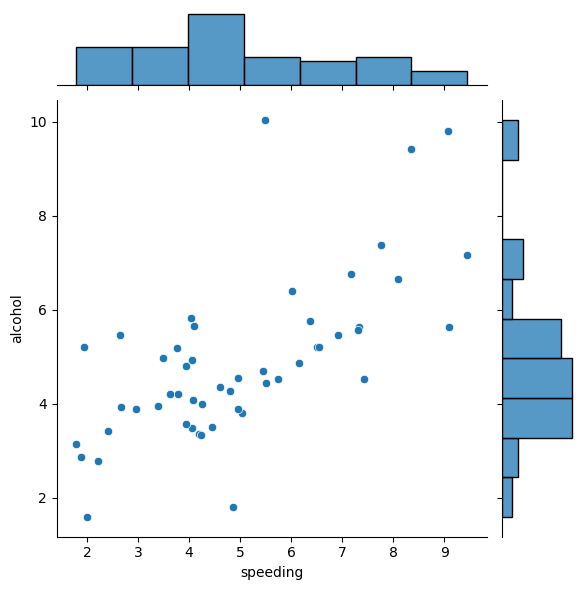

In [6]:
sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='scatter')

### KDE Plot

<Axes: xlabel='alcohol', ylabel='Density'>

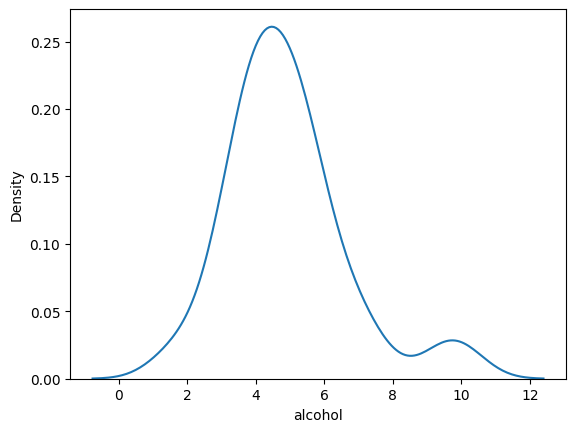

In [7]:
sns.kdeplot(crash_df['alcohol'])

### Pair Plots

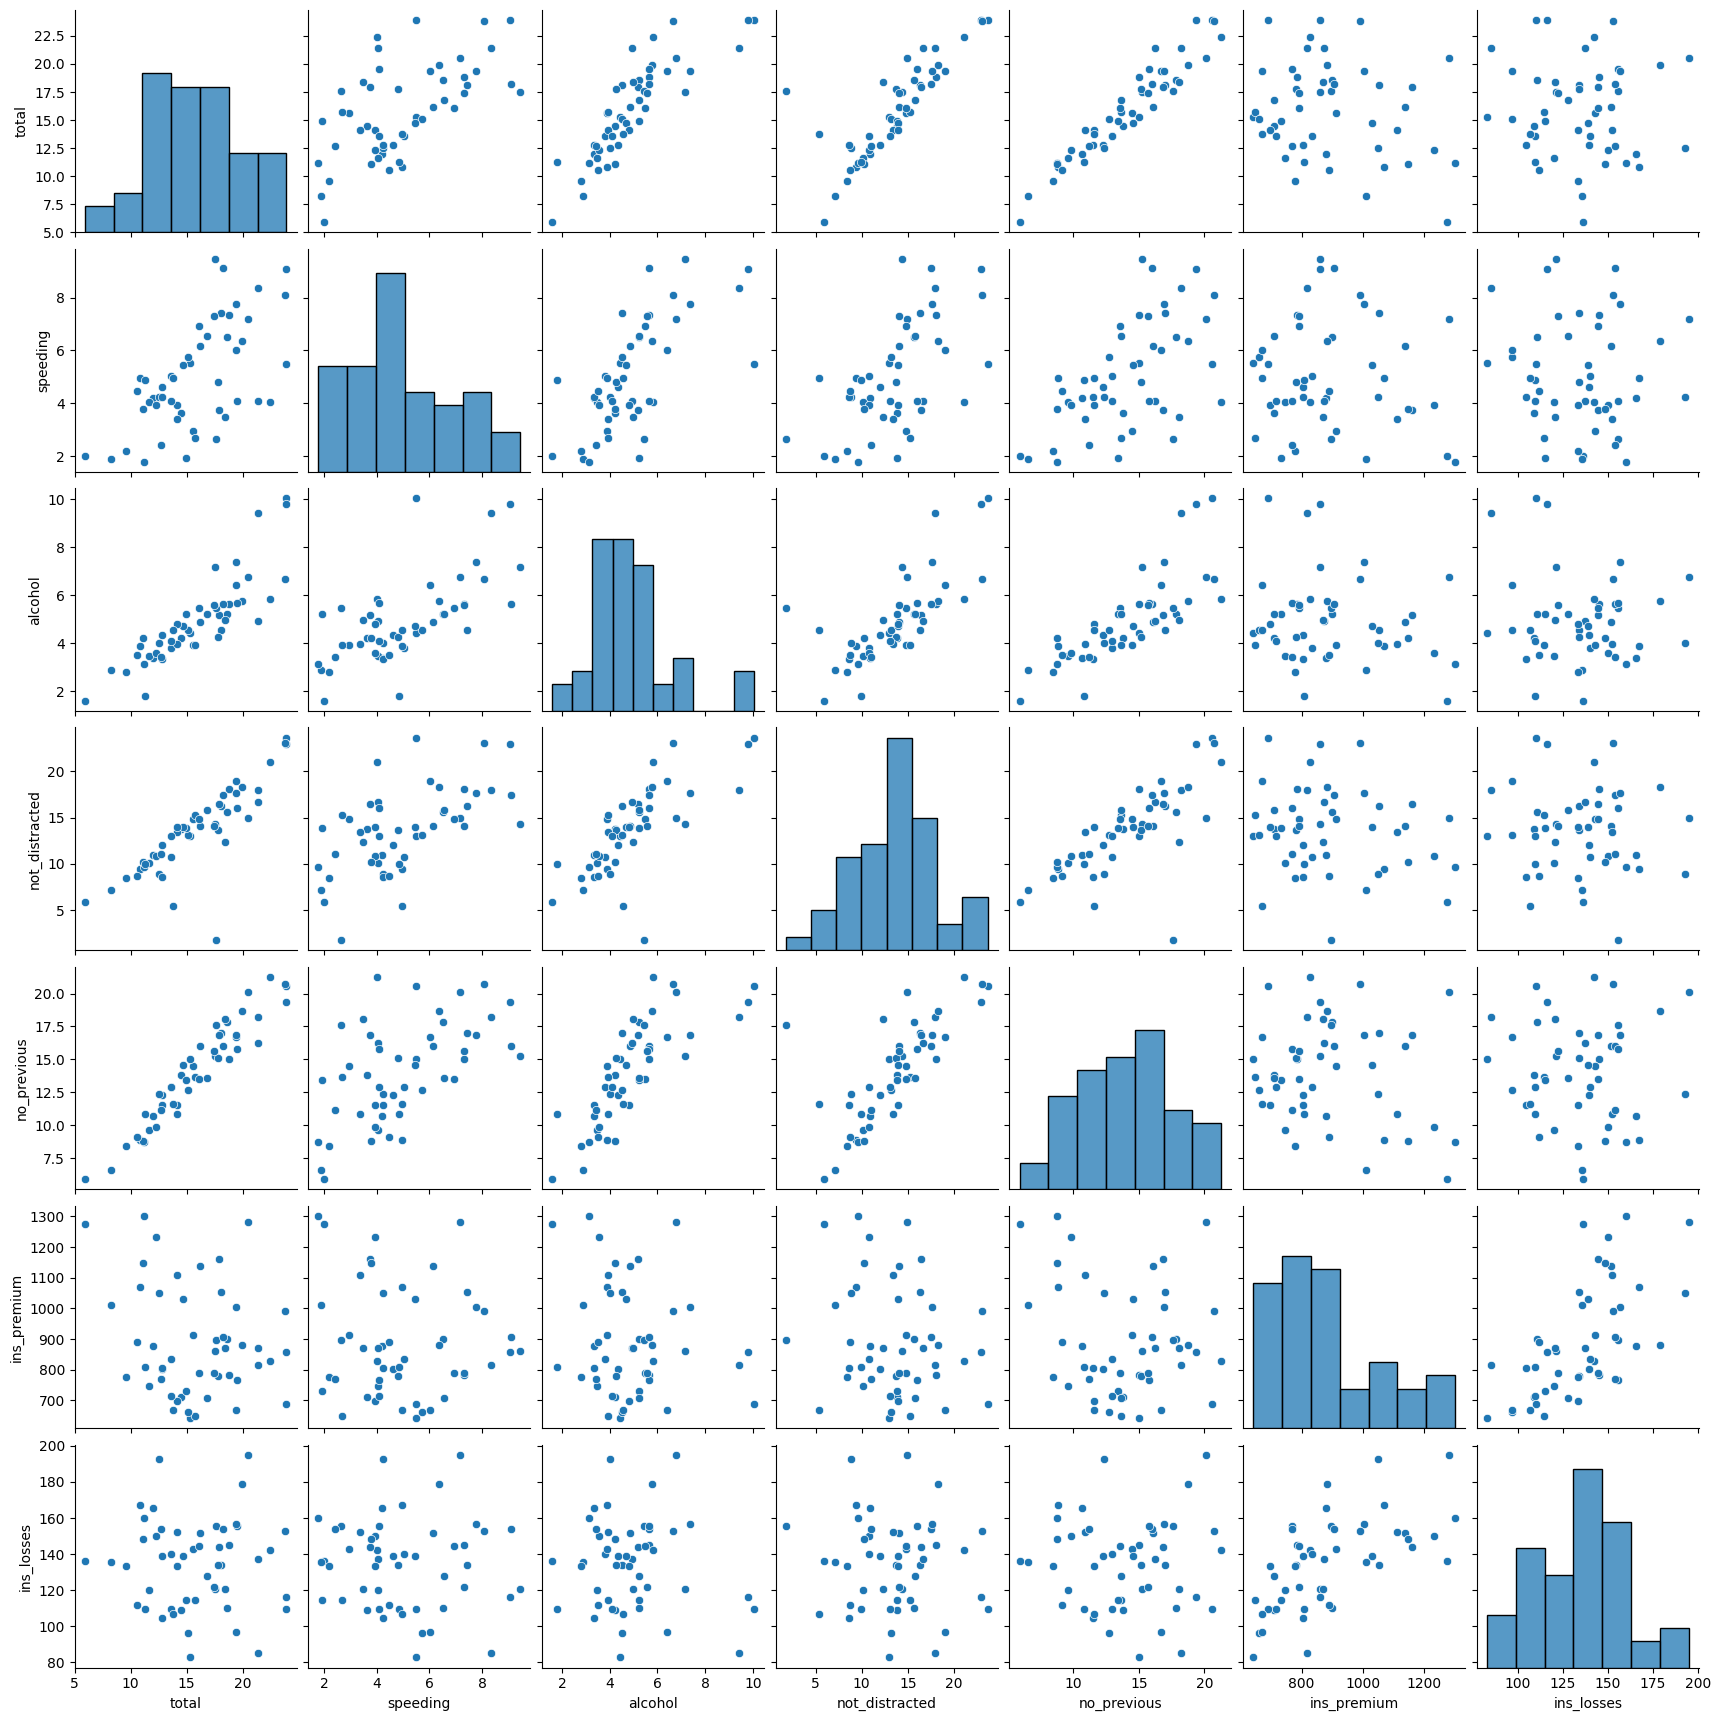

In [8]:
sns.pairplot(crash_df)

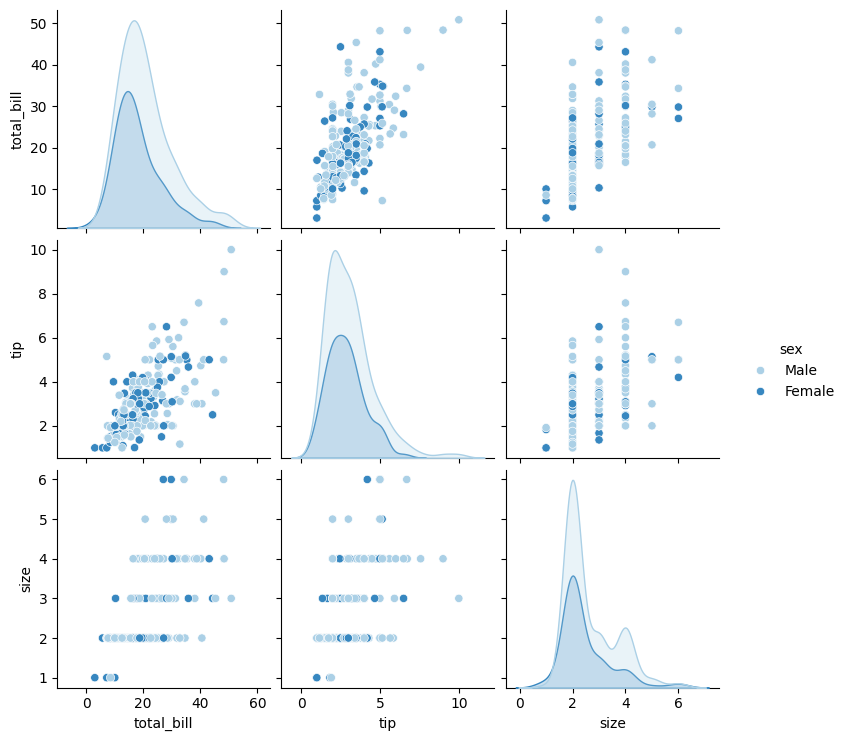

In [9]:
tips_df = sns.load_dataset('tips')

sns.pairplot(tips_df, hue='sex', palette='Blues')

### Rug Plot

<Axes: xlabel='tip'>

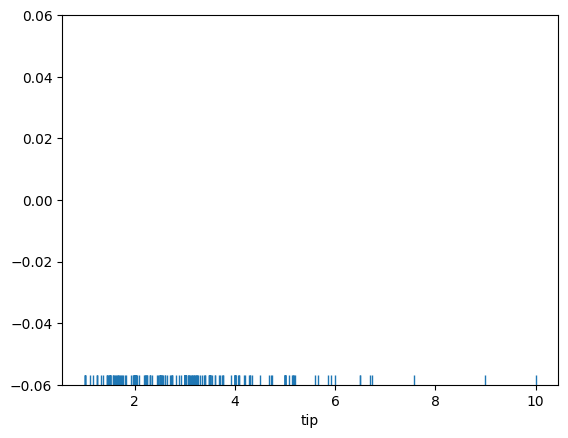

In [10]:
sns.rugplot(tips_df['tip'])

# Styling

<Figure size 800x400 with 0 Axes>

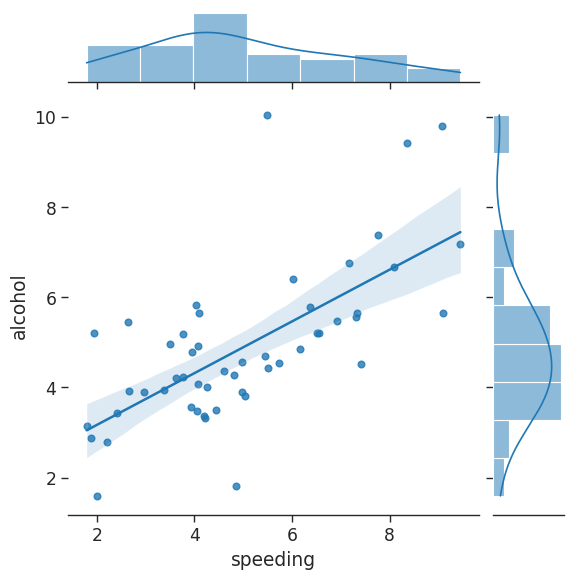

In [11]:
sns.set_style('ticks')
plt.figure(figsize=(8,4))
sns.set_context('paper', font_scale=1.4)

sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='reg')

sns.despine(left=True) # Removes the left spines from the plot, giving it a cleaner look.

# Categorical Plots

### Bar Plot

<Axes: xlabel='sex', ylabel='total_bill'>

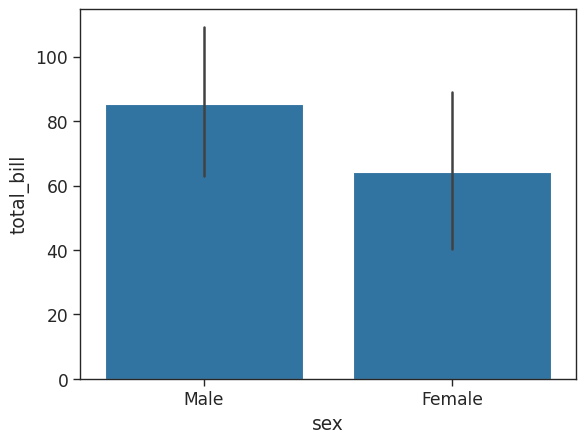

In [12]:
sns.barplot(x='sex', y='total_bill', data=tips_df, estimator=np.cov)

### Count Plot

<Axes: xlabel='sex', ylabel='count'>

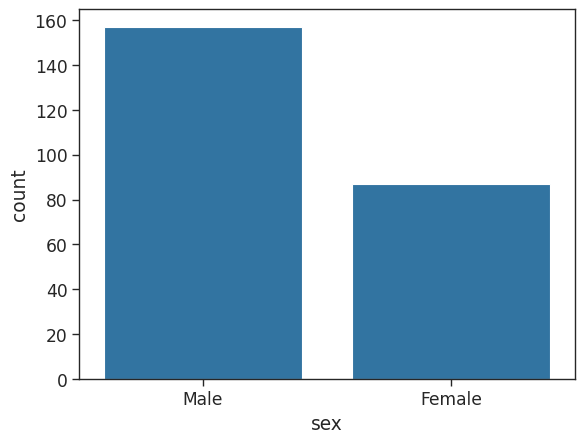

In [13]:
sns.countplot(x='sex', data=tips_df)

### Box Plot

<Axes: xlabel='day', ylabel='total_bill'>

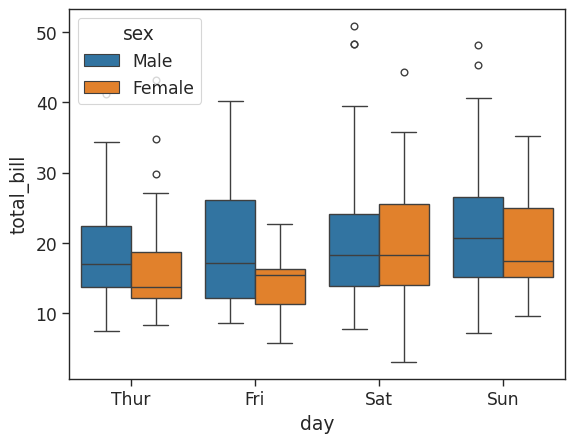

In [14]:
sns.boxplot(x='day', y='total_bill', data=tips_df, hue='sex')

### Violin Plot

<Axes: xlabel='day', ylabel='total_bill'>

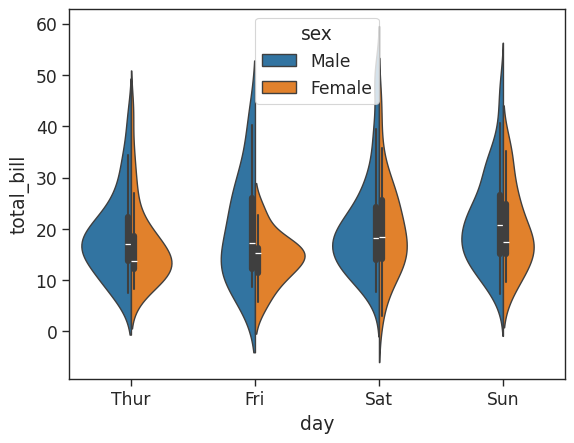

In [15]:
sns.violinplot(x='day', y='total_bill', data=tips_df, hue='sex', split=True)

### Strip Plot

<Axes: xlabel='day', ylabel='total_bill'>

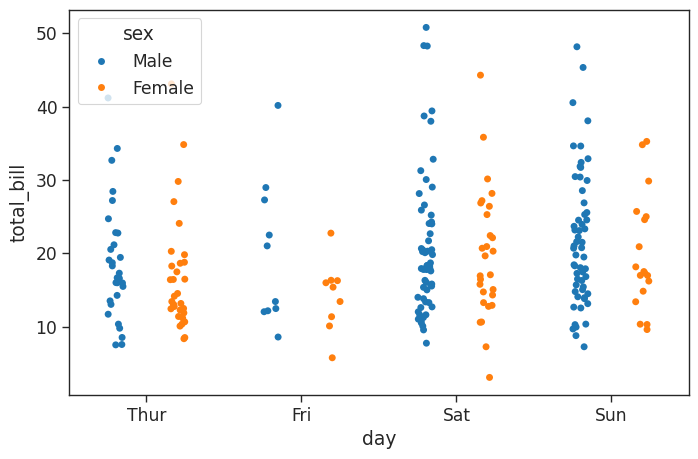

In [16]:
plt.figure(figsize=(8,5))
sns.stripplot(x='day', y='total_bill', data=tips_df, jitter=True, hue='sex', dodge=True)
# jitter to spread out the points and avoid overlap, making it easier to see individual data points.
# dodge to separate the points based on the hue variable, allowing for better comparison between categories.

### Swarm Plot

<Axes: xlabel='day', ylabel='total_bill'>

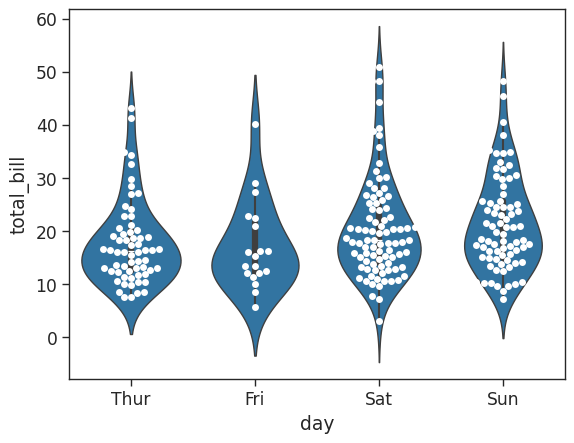

In [17]:
sns.violinplot(x='day', y='total_bill', data=tips_df)
sns.swarmplot(x='day', y='total_bill', data=tips_df, color='white')

# Palettes

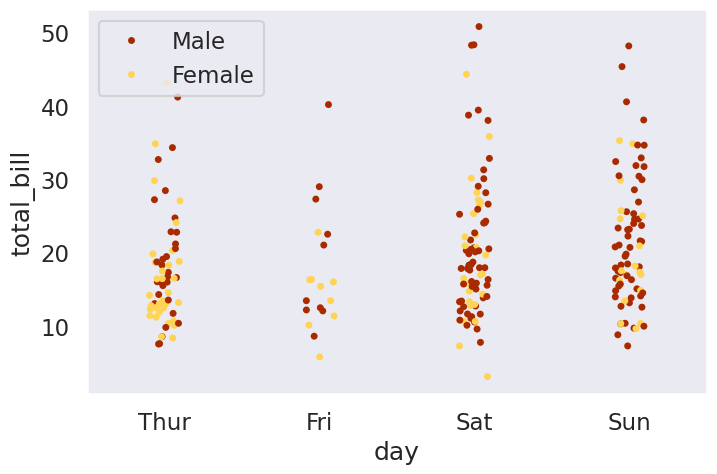

In [20]:
plt.figure(figsize=(8,5))
sns.set_style('dark')
sns.set_context('talk')
sns.stripplot(x='day', y='total_bill', data=tips_df, hue='sex', palette='afmhot')
plt.legend(loc=0)

# Matrix Plots

### Heatmaps

<Axes: >

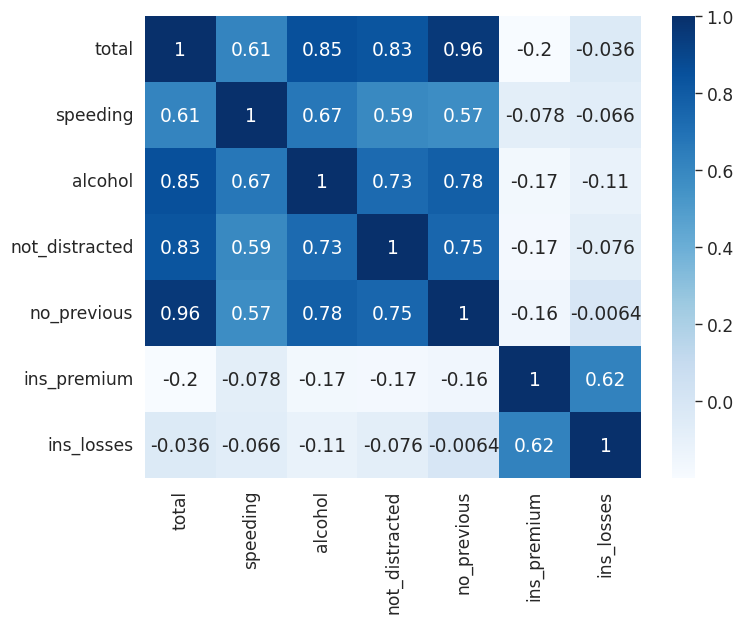

In [26]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

crash_mx = crash_df.select_dtypes(include=['number']).corr()

sns.heatmap(crash_mx, annot=True, cmap='Blues')

### Cluster Map

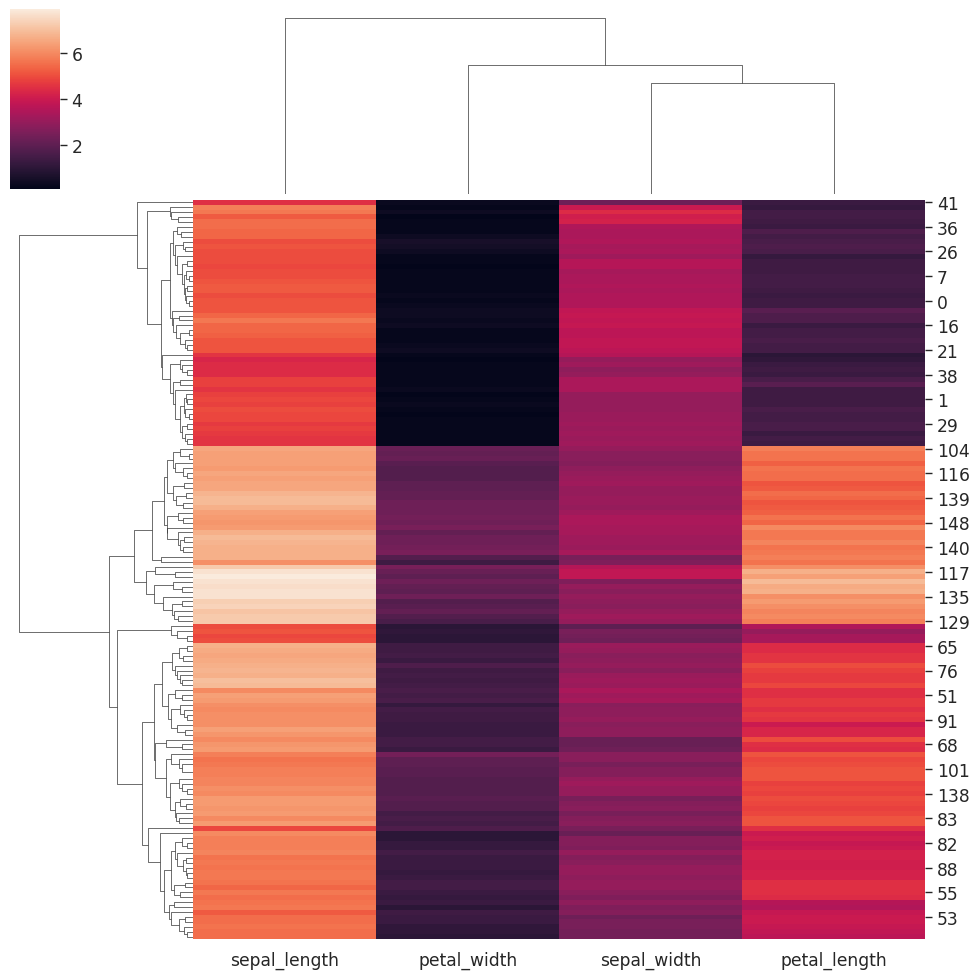

In [28]:
iris = sns.load_dataset('iris')
species = iris.pop('species')
sns.clustermap(iris)

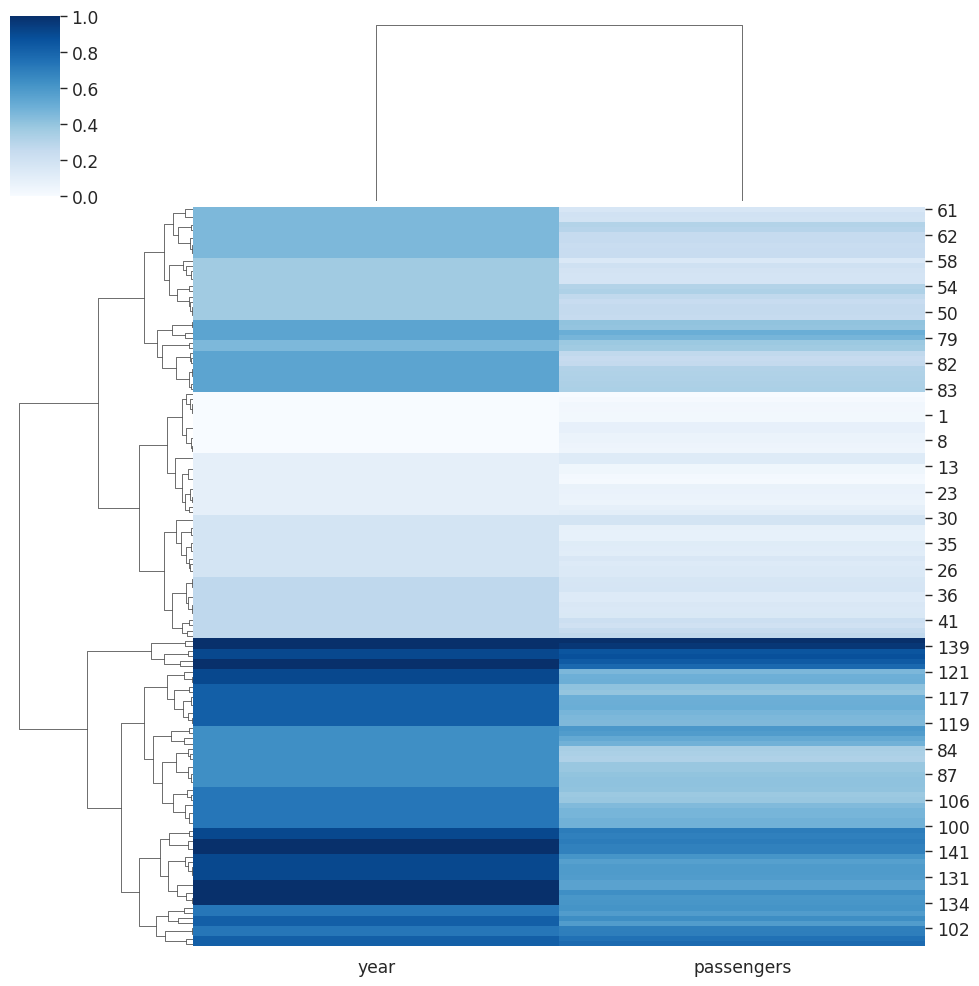

In [35]:
flights = sns.load_dataset('flights')
flights.pop('month')
sns.clustermap(flights, cmap='Blues', standard_scale=1)

### Pair Grid

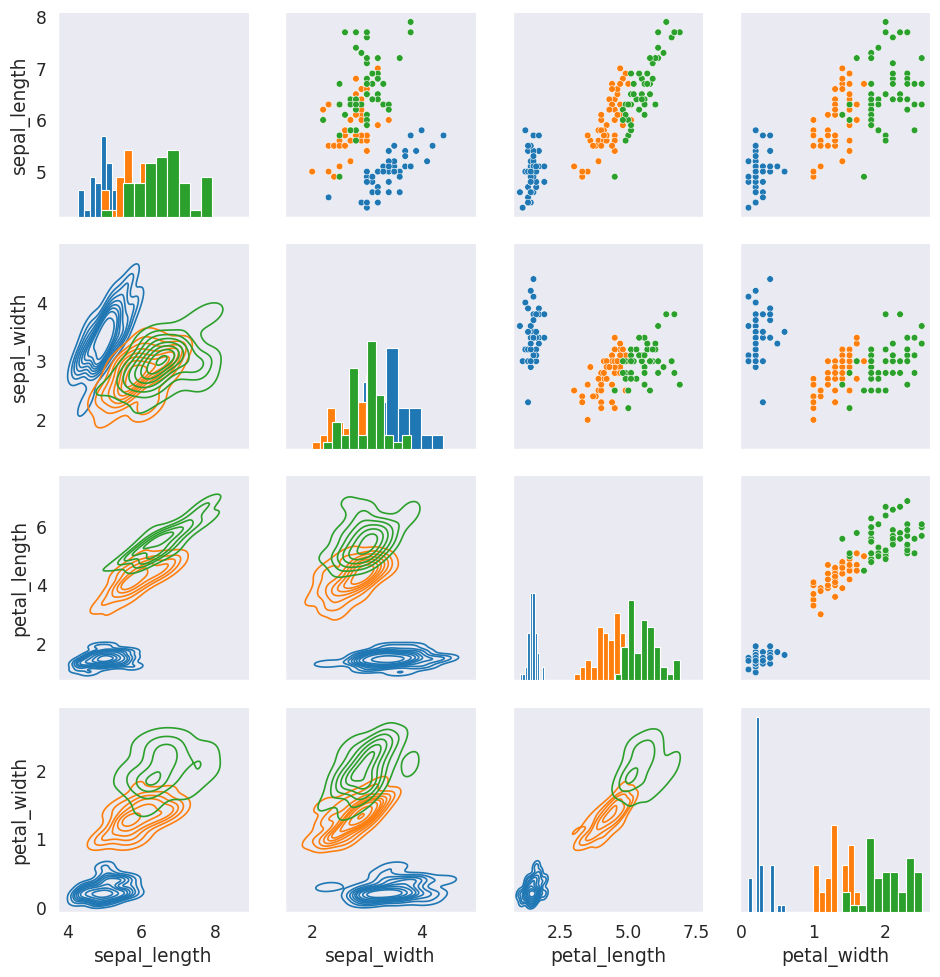

In [44]:
iris = sns.load_dataset('iris')
iris_g = sns.PairGrid(iris, hue='species')
# iris_g.map(sns.scatterplot)
iris_g.map_diag(plt.hist)
#iris_g.map_offdiag(sns.scatterplot)
iris_g.map_upper(sns.scatterplot)
iris_g.map_lower(sns.kdeplot)

### Facet Grid

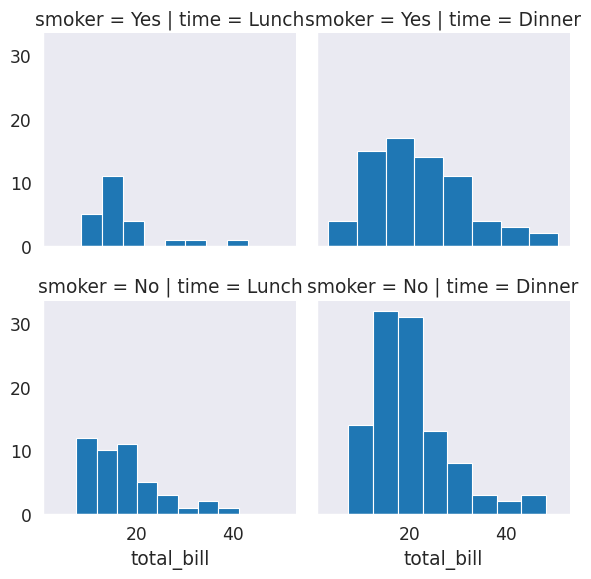

In [47]:
tips_fg = sns.FacetGrid(tips_df, col='time', row='smoker')
tips_fg.map(plt.hist, 'total_bill', bins=8)

# Regression Plots

<Figure size 800x600 with 0 Axes>

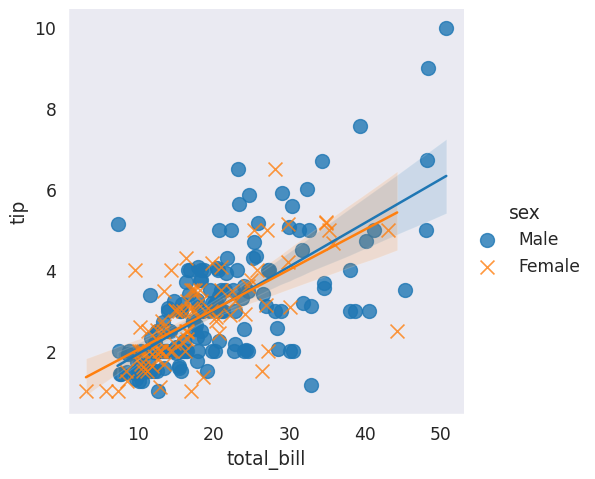

In [55]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
sns.lmplot(x='total_bill', y='tip', data=tips_df, hue='sex', markers=['o', 'x'], scatter_kws={'s': 100})